# 뉴스 카테고리 예측 모델 개발

과제식별 : [스프린트 미션10](https://www.codeit.kr/topics/studyGroupStep6985c080aa647f3831b0de75/lessons/13927)  
작성 : 2026.05.15 신호정

## A. 프로젝트의 목적

뉴스 문서를 입력받으면 해당 뉴스가 어떤 카테고리에 속하는지 예측하는 모델을 개발합니다.  
임베딩된 데이터 셋을 기반으로 학습된 RNN 모델을 사용하며  
Word2Vec, FastText, GloVe 각각의 임베딩 방식 별 모델 성능을 평가합니다.

### a. 프로젝트 수행방향
sklearn 에서 제공하는 news Group 20 데이터를 원본으로 사용합니다.  
위 데이터에 다음의 텍스트 임베딩을 적용합니다 : Word2Vec, FastText, GloVe  
데이터 셋을 구현한 후 GRU or LSTM 기반의 RNN 모델을 구현합니다.  
각각의 임베딩 별 RNN 모델의 성능을 측정합니다.

### b. 프로젝트 수행계획

1. 프로젝트 수행방향에서 언급된 임베딩 별 모델 성능을 측정하기 위한 구조를 정의합니다.

2. 뉴스 카테고리가 어떻게 구분되는지를 조사하고 정리합니다.

3. 학습에 사용될 데이터를 확인하고 특성을 정리 후 클랜징 및 토큰화 전략을 수립 후 적용합니다.

4. GRU 와 LSTM 기반의 RNN 모델의 특성과 성능 차이를 조사 후 모델을 구현합니다.

5. 프로젝트 수행에 필요한 기반 환경을 설정합니다.

6. 각 임베딩 방법 별로 학습을 진행하며, 도출되는 로그를 수집합니다.

7. 각 임베딩 적용된 모델 별 평가 지표를 산출하고 의미를 정리합니다.

### c. 프로젝트 변인 정의

본 프로젝트에서의 변인을 표로 정의하면 다음과 같습니다.

| 구분 | 내용 |
|------|------|
| 독립 변인 | 임베딩 방식 (Word2Vec, FastText, GloVe), RNN 구조 |
| 통제 변인 | 히든 차원, 학습률, Epoch, Seed 등 |
| 비교 기준 | Accuracy, Precision, Recall, F1-score |

## B. 임베딩 별 모델 성능 측정 구조 설계

### a. 구조적 문제 예측

3개의 임베딩을 각각의 셀에 분산하여 구현하면 코드의 가독성이 악화될 위험이 있습니다.

### b. 문제 해결을 위한 구조 설계

다음과 같이 셀 구조를 정의합니다.

1. EmbeddingType 을 정의하여 개별 임베딩을 구분할 플래그 정의

2. 임베딩 로더 함수를 정의하고 1항에서 정의된 플래그 별 임베딩 메트릭스를 반환하도록 구성

3. RNN 모델은 2항에서 생성한 임베딩 메트릭스를 인자로 받아 작동하는 공용 구조로 구현

4. 학습 진행 후 임베딩 별 상태를 pt 파일로 저장하여 이후 평가에서 복원하여 일괄 비교

## C. 뉴스 카테고리의 의미와 분류

### a. 뉴스 카테고리의 발전 과정

#### 1. 초기 신문(17세기 ~ 산업 혁명 전)의 특징과 독자들의 고충
기사가 입수된 순서대로, 혹은 편집자가 중요하다고 생각하는 순서대로 무작위 배치되었습니다.  
따라서 독자는 원하는 정보의 위치를 예측할 수 없었으며, 신문 전체를 처음부터 끝까지 읽어야 했습니다.

#### 2. 산업 혁명과 윤전기를 통한 신문의 발전
윤전기와 종이 가격 하락으로 많은 부수를 발행하는 대중지가 등장하게 되었습니다.  
신문의 페이지 수가 늘어남에 따라 독자가 원하는 정보를 빨리 찾을 수 있도록 레이아웃이 구조화 되었습니다.  
이 때부터 구독자 중심의 수익구조가 아닌 광고 중심의 수익 구조로 변하게 되었습니다.  
이에 따라 상품을 소개하기 위한 '가정', '상업' 등의 타겟 맞춤형 섹션이 생겨나게 되었습니다.

#### 3. 전문 기자 제도와 데스크 시스템(20세기 초중반)
뉴스 조직이 거대해지면서 정보 생산의 효율성을 위해 '데스크'시스템이 도입되었습니다.  
정치, 사회, 경제, 스포츠 등의 전문 분야를 담당하는 기자가 작성한 기사를  
담당한 분야 그대로 신문의 레이아웃 구성에 따라 수록하는 시스템입니다.

#### 4. 디지털 전환과 메타데이터(1990년대 ~ 2000년대 초)
신문이 종이를 벗어나 인터넷으로 배포되기 시작합니다.  
검색 엔진이 기사를 검색할 수 있도록 메타데이터를 붙이기 시작하여,  
하나의 기사가 여러 카테고리에 속할 수 있는 '다중 분류'가 가능해졌습니다.

#### 5. 알고리즘과 클러스터링(현재)
이제는 AI를 통해 카테고리를 분류하고 제공합니다.  
자연어 처리 기술을 통해 실시간으로 등록되는 기사들을 유사한 주제끼리 묶는 클러스터링을 수행합니다.(Topic Modeling)  
본 프로젝트로 생성된 모델이 이 클러스터링의 일부를 수행할 수 있습니다.  
또한 사용자의 클릭 로그를 기반으로 '관심 주제'라는 동적 카테고리를 생성합니다.

### b. 한국 뉴스 미디어의 표준적인 대분류

| 대분류    | 주요 하위 카테고리 (Sub-sections)        | 설명 및 특징                                                     |
|--------|----------------------------------|-------------------------------------------------------------|
| 정치     | 대통령실, 국회/정당, 북한, 국방/외교, 행정       | 한국 특유의 '북한' 섹션이 독립적이거나 정치의 핵심 비중을 차지하는 것이 특징입니다.            |
| 경제     | 금융, 증권, 산업/재계, 부동산, 글로벌 경제, 소비자  | **'부동산'** 에 대한 대중적 관심도가 매우 높아 별도 섹션으로 강조되는 경우가 많습니다.         |
| 사회     | 사건사고, 교육, 노동, 언론, 환경, 지역         | 미국 뉴스의 'National'에 해당하지만, 범죄 및 사회 구조적 담론이 모두 포함된 포괄적 섹션입니다. |
| 생활/문화  | 건강, 여행/레저, 식품/맛집, 자동차, 종교, 공연/전시 | 라이프스타일 전반을 다루며, 최근에는 '건강'과 'MZ세대 트렌드' 비중이 높습니다.             |
| 세계     | 미국/미주, 유럽, 아시아/호주, 중동/아프리카       | 해외 통신사 기사나 특파원 리포트를 중심으로 구성됩니다.                             |
| IT/과학  | 모바일, 통신/뉴미디어, IT 일반, 과학 일반, 게임   | 한국의 강점인 반도체, 통신, 게임 산업 뉴스가 집중적으로 다뤄집니다.                     |
| 오피니언   | 사설, 칼럼, 기고, 만평                   | 팩트 중심 보도와 필진의 주관적 견해를 분리하여 제공합니다.                           |
| 연예/스포츠 | 연예가 소식, 영화, 방송, 야구, 축구, 해외축구     | 트래픽이 가장 많이 발생하는 섹션으로, 포털에서는 일반 뉴스 섹션과 별도로 분리하기도 합니다.        |


### c. 현대 미국 뉴스 미디어의 표준적인 대분류

| 대분류                     | 주요 내용 및 특징                                                                    |
|-------------------------|-------------------------------------------------------------------------------|
| National (U.S.)         | 백악관, 의회(Congress), 연방 정부 정책, 대선 및 선거, 사회적 이슈(인종, 총기, 낙태 등) 등 미국 내 정치를 총괄합니다.  |
| World (International)   | 지정학적 갈등, 외교 관계, 해외 주요 사건. 특히 중동, 중국, 유럽 관련 비중이 높습니다.                          |
| Politics                | National과 겹치기도 하지만, 주로 정당 간의 정쟁, 정치 전략, 여론 조사 등에 특화된 섹션입니다.                   |
| Business / Economy      | 월스트리트 시장 상황, 기업 실적, 노동 시장, 인플레이션, 연준(Fed)의 금리 정책 등을 다룹니다.                     |
| Technology              | 실리콘밸리 기업(Big Tech), AI/신기술 트렌드, 사이버 보안, 소비자 가전 등을 다루며 기술의 사회적 영향을 중시합니다.      |
| Science & Health        | 우주 탐사, 기후 변화, 공공 보건(의학 연구, 팬데믹 대응), 최신 과학 논문 요약 등이 포함됩니다.                     |
| Entertainment & Culture | 할리우드, 팝 문화, 예술, 미디어 산업 분석, 도서 및 영화 리뷰를 다룹니다.                                  |
| Sports                  | NFL(미식축구), NBA(농구), MLB(야구) 등 북미 4대 스포츠 중심의 경기 결과 및 비즈니스 분석입니다.               |
| Opinion / Editorial     | 해당 언론사의 논조를 보여주는 사설, 외부 기고가(Columnist)의 분석. 사실(Fact)과 의견(Opinion)을 엄격히 구분합니다. |
| Lifestyle / Style       | 여행, 요식, 주거, 패션, 웰빙 등 개인의 삶의 질과 관련된 연성 뉴스(Soft News) 섹션입니다.                    |


## D. news Group 20 데이터 분석 및 전처리

sklearn에서 제공한 news Group 20에 대한 데이터 분석을 진행합니다.  
균일한 내용 출력을 위해 필요한 공용 기능을 먼저 구현합니다.

In [153]:
# 범용 로그 설정
import logging

logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s.%(msecs)03d] [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)

logger = logging.getLogger(__name__)

In [154]:
import sys                                  # 시스템 관련 기능 (Colab 환경 감지)
import subprocess                           # Colab 환경 한글 폰트 설정
import matplotlib.pyplot as plt             # 그래프 및 이미지 시각화
import matplotlib.font_manager as fm        # 한글 폰트 등록 및 관리

try:
    is_colab = 'google.colab' in sys.modules

    if is_colab:
        logger.info("Colab 환경 감지: 한글 폰트 설치 중...")
        subprocess.run(
            ["apt-get", "-qq", "install", "-y", "fonts-nanum"],
            check=True,
            capture_output=True,
        )
        FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    else:
        logger.info("Colab 환경이 아님: 시스템에 설치된 한글 폰트 사용 시도...")
        FONT_PATH = "NanumGothic.ttf"

    fm.fontManager.addfont(FONT_PATH)
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
    plt.rcParams["font.sans-serif"] = ["NanumGothic"]
    logger.info(f"한글 폰트 설정 완료: {FONT_PATH}")
except Exception as e:
    logger.warning(f"한글 폰트 설치 실패 (영문 폰트로 대체): {e}")

[2026-05-15 15:48:55.215] [INFO] Colab 환경이 아님: 시스템에 설치된 한글 폰트 사용 시도...
[2026-05-15 15:48:55.232] [INFO] 한글 폰트 설정 완료: NanumGothic.ttf


In [155]:
import os

MOUNT_PATH = "/content/drive"

if is_colab:
    logger.info("Colab 환경 감지하여 Google Drive 마운트 시도...")
    from google.colab import drive
    target_path = os.path.join(MOUNT_PATH, "MyDrive")

    if not os.path.exists(target_path):
        drive.mount(MOUNT_PATH)
else:
    logger.info("Colab 환경이 아님: Google Drive 마운트 생략")

[2026-05-15 15:48:55.243] [INFO] Colab 환경이 아님: Google Drive 마운트 생략


### a. 원본 데이터 로드 및 내용 출력 확인

In [156]:
from sklearn.datasets import fetch_20newsgroups

import pandas as pd

newsgroups_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

newsgroups_origin_df = pd.DataFrame({
    'text': newsgroups_data.data,
    'label': newsgroups_data.target
})

logger.info(f"문서 수: {newsgroups_origin_df['label'].count()}\n")
logger.info(f"샘플 문서:{newsgroups_origin_df['text'][0]}")
logger.info(f"고유 라벨 수: {len(set(newsgroups_origin_df['label']))}")

newsgroups_origin_df

[2026-05-15 15:48:56.367] [INFO] 문서 수: 18846

[2026-05-15 15:48:56.369] [INFO] 샘플 문서:

I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


[2026-05-15 15:48:56.370] [INFO] 고유 라벨 수: 20


,text,label
0,\n\nI am sure some bashers of Pens fans are pr...,10
1,My brother is in the market for a high-perform...,3
2,\n\n\n\n\tFinally you said what you dream abou...,17
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3
4,1) I have an old Jasmine drive which I cann...,4
...,...,...
18841,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...,13
18842,\nNot in isolated ground recepticles (usually ...,12
18843,I just installed a DX2-66 CPU in a clone mothe...,3
18844,\nWouldn't this require a hyper-sphere. In 3-...,1


### b. 데이터 내의 카테고리 확인

In [157]:
category_names = newsgroups_data.target_names

logger.info(f"총 카테고리 수: {len(category_names)}")
logger.info("카테고리 목록:")
for i, category in enumerate(category_names):
    logger.info(f"  {i}: {category}")

[2026-05-15 15:48:56.395] [INFO] 총 카테고리 수: 20
[2026-05-15 15:48:56.396] [INFO] 카테고리 목록:
[2026-05-15 15:48:56.397] [INFO]   0: alt.atheism
[2026-05-15 15:48:56.398] [INFO]   1: comp.graphics
[2026-05-15 15:48:56.399] [INFO]   2: comp.os.ms-windows.misc
[2026-05-15 15:48:56.399] [INFO]   3: comp.sys.ibm.pc.hardware
[2026-05-15 15:48:56.399] [INFO]   4: comp.sys.mac.hardware
[2026-05-15 15:48:56.400] [INFO]   5: comp.windows.x
[2026-05-15 15:48:56.400] [INFO]   6: misc.forsale
[2026-05-15 15:48:56.401] [INFO]   7: rec.autos
[2026-05-15 15:48:56.401] [INFO]   8: rec.motorcycles
[2026-05-15 15:48:56.402] [INFO]   9: rec.sport.baseball
[2026-05-15 15:48:56.402] [INFO]   10: rec.sport.hockey
[2026-05-15 15:48:56.403] [INFO]   11: sci.crypt
[2026-05-15 15:48:56.403] [INFO]   12: sci.electronics
[2026-05-15 15:48:56.404] [INFO]   13: sci.med
[2026-05-15 15:48:56.404] [INFO]   14: sci.space
[2026-05-15 15:48:56.404] [INFO]   15: soc.religion.christian
[2026-05-15 15:48:56.406] [INFO]   16: talk.

로그에서 확인할 수 있듯, 20개의 카테고리가 존재합니다.  
각 카테고리의 의미는 다음과 같습니다.

| 대분류 | 세부 카테고리(Target Name) | 설명 |
|------------|--------------------------|--------------------------------------|
| Computers  | comp.graphics            | 컴퓨터 그래픽스 알고리즘, 라이브러리, 이미지 포맷 등       |
|            | comp.os.ms-windows.misc  | Microsoft Windows 운영체제 관련 일반 질문 및 이슈 |
|            | comp.sys.ibm.pc.hardware | IBM 호환 PC 하드웨어 사양 및 문제 해결            |
|            | comp.sys.mac.hardware    | Apple Macintosh 하드웨어 관련 논의           |
|            | comp.windows.x           | X Window 시스템 기술 정보 및 설정              |
| Science    | sci.crypt                | 암호학, 보안 알고리즘, PGP 등                  |
|            | sci.electronics          | 회로 설계, 전자 부품, 하드웨어 엔지니어링             |
|            | sci.med                  | 의학 정보, 질병, 건강 관리 및 생물학               |
|            | sci.space                | 우주 탐사, 천문학, NASA 관련 뉴스               |
| Recreation | rec.autos                | 자동차 모델 정보, 수리, 구매 상담                 |
|            | rec.motorcycles          | 오토바이 관련 논의 및 라이딩 문화                  |
|            | rec.sport.baseball       | 메이저리그 등 야구 경기 분석 및 통계                |
|            | rec.sport.hockey         | NHL 등 하키 경기 및 팀 소식                   |
| Politics   | talk.politics.guns       | 총기 소지 권리 및 규제에 대한 정치적 논의             |
|            | talk.politics.mideast    | 중동 지역 정치, 분쟁 및 국제 관계                 |
|            | talk.politics.misc       | 일반적인 정치 이슈 및 정부 정책 논의                |
| Religion   | alt.atheism              | 무신론에 관한 비판 및 철학적 논의                  |
|            | soc.religion.christian   | 기독교 교리, 성경 해석 및 교회 활동                |
|            | talk.religion.misc       | 여러 종교 간의 비교 및 기타 종교적 주제              |
| Misc       | misc.forsale             | 중고 물품 판매, 구매 희망 광고 (장터)              |


### c. 카테고리 별 문서의 수 확인

In [158]:
import numpy as np

unique_elements, counts_elements = np.unique(newsgroups_origin_df['label'], return_counts=True)

for category, count in zip(unique_elements, counts_elements):
    category_name = category_names[category]
    logger.info(f"'{category_name}'의 문서 수: {count}")

[2026-05-15 15:48:56.419] [INFO] 'alt.atheism'의 문서 수: 799
[2026-05-15 15:48:56.420] [INFO] 'comp.graphics'의 문서 수: 973
[2026-05-15 15:48:56.421] [INFO] 'comp.os.ms-windows.misc'의 문서 수: 985
[2026-05-15 15:48:56.421] [INFO] 'comp.sys.ibm.pc.hardware'의 문서 수: 982
[2026-05-15 15:48:56.422] [INFO] 'comp.sys.mac.hardware'의 문서 수: 963
[2026-05-15 15:48:56.422] [INFO] 'comp.windows.x'의 문서 수: 988
[2026-05-15 15:48:56.423] [INFO] 'misc.forsale'의 문서 수: 975
[2026-05-15 15:48:56.423] [INFO] 'rec.autos'의 문서 수: 990
[2026-05-15 15:48:56.424] [INFO] 'rec.motorcycles'의 문서 수: 996
[2026-05-15 15:48:56.424] [INFO] 'rec.sport.baseball'의 문서 수: 994
[2026-05-15 15:48:56.424] [INFO] 'rec.sport.hockey'의 문서 수: 999
[2026-05-15 15:48:56.425] [INFO] 'sci.crypt'의 문서 수: 991
[2026-05-15 15:48:56.425] [INFO] 'sci.electronics'의 문서 수: 984
[2026-05-15 15:48:56.425] [INFO] 'sci.med'의 문서 수: 990
[2026-05-15 15:48:56.426] [INFO] 'sci.space'의 문서 수: 987
[2026-05-15 15:48:56.426] [INFO] 'soc.religion.christian'의 문서 수: 997
[2026-05-1

클래스 별 문서 수는 628 ~ 999개 수준으로, 심각한 클래스 불균형은 아닌 것으로 판단합니다.  
따라서 단순 샘플 수 부족으로 인한 학습 불안정 가능성은 낮아 보입니다.

### d. 카테고리 별 문서 길이 분포 분석

각 문서의 문자 수, 단어 수, 문장 수를 카테고리 별로 최대, 최소, 평균을 산출하여 비교합니다.  
이를 통해 카테고리 별 문서의 길이 특성을 파악하고 모델에 필요한 padding 값을 산출할 수 있습니다.

In [159]:

newsgroups_origin_df['category'] = newsgroups_origin_df['label'].apply(lambda x: category_names[x])
newsgroups_origin_df['char_length'] = newsgroups_origin_df['text'].apply(len)
newsgroups_origin_df['word_count'] = newsgroups_origin_df['text'].apply(lambda x: len(x.split()))

stats = newsgroups_origin_df.groupby('category')['word_count'].agg(['min', 'max', 'mean', 'median', 'std'])
stats = stats.round(2)
stats.columns = ['min_word_length', 'max_word_length', 'mean_word_length', 'median_word_length', 'std_word_length']

logger.info("카테고리별 단어 수 통계:")
stats

[2026-05-15 15:48:56.577] [INFO] 카테고리별 단어 수 통계:


,min_word_length,max_word_length,mean_word_length,median_word_length,std_word_length
category,,,,,
alt.atheism,0,8611,196.89,91.0,484.17
comp.graphics,0,9196,196.84,65.0,811.68
comp.os.ms-windows.misc,0,5219,134.56,69.0,303.54
comp.sys.ibm.pc.hardware,0,3983,125.58,79.0,242.85
comp.sys.mac.hardware,0,7754,111.59,70.0,353.00
comp.windows.x,0,9365,219.14,80.0,823.68
misc.forsale,0,2625,107.90,63.0,182.24
rec.autos,0,4387,113.13,71.0,216.85
rec.motorcycles,0,5498,100.12,59.5,200.79


분석 결과 모든 카테고리의 'min_word_length'에서 0 단어가 관측되었습니다.  
이것은 명백한 이상치로, 카테고리 내의 내용 없는 문서와  
모델이 의미를 구성하기 힘든 3 단어 이하를 제거 후에 다시 통계를 집계하겠습니다.

### e. 기준 이하 단어 수록 문서 제거 및 통계 확인

In [160]:
# word_count 내에 3개 이하의 단어를 가진 문서를 확인하고 제거
newsgroups_refined_df = newsgroups_origin_df[newsgroups_origin_df['word_count'] > 3].copy()

stats = newsgroups_refined_df.groupby('category')['word_count'].agg(['min', 'max', 'mean', 'median', 'std'])
stats = stats.round(2)
stats.columns = ['min_word_count', 'max_word_count', 'mean_word_count', 'median_word_count', 'std_word_count']

unique_elements, counts_elements = np.unique(newsgroups_refined_df['label'], return_counts=True)

logger.info("필터링 후 카테고리별 문서 수:")
for category, count in zip(unique_elements, counts_elements):
    category_name = category_names[category]
    logger.info(f"'{category_name}'의 문서 수: {count}")

logger.info("\n카테고리별 단어 수 통계:")
stats

[2026-05-15 15:48:56.608] [INFO] 필터링 후 카테고리별 문서 수:
[2026-05-15 15:48:56.609] [INFO] 'alt.atheism'의 문서 수: 776
[2026-05-15 15:48:56.609] [INFO] 'comp.graphics'의 문서 수: 948


[2026-05-15 15:48:56.609] [INFO] 'comp.os.ms-windows.misc'의 문서 수: 942
[2026-05-15 15:48:56.610] [INFO] 'comp.sys.ibm.pc.hardware'의 문서 수: 960
[2026-05-15 15:48:56.610] [INFO] 'comp.sys.mac.hardware'의 문서 수: 923
[2026-05-15 15:48:56.611] [INFO] 'comp.windows.x'의 문서 수: 967
[2026-05-15 15:48:56.611] [INFO] 'misc.forsale'의 문서 수: 951
[2026-05-15 15:48:56.612] [INFO] 'rec.autos'의 문서 수: 925
[2026-05-15 15:48:56.612] [INFO] 'rec.motorcycles'의 문서 수: 958
[2026-05-15 15:48:56.612] [INFO] 'rec.sport.baseball'의 문서 수: 941
[2026-05-15 15:48:56.613] [INFO] 'rec.sport.hockey'의 문서 수: 970
[2026-05-15 15:48:56.613] [INFO] 'sci.crypt'의 문서 수: 959
[2026-05-15 15:48:56.614] [INFO] 'sci.electronics'의 문서 수: 953
[2026-05-15 15:48:56.615] [INFO] 'sci.med'의 문서 수: 956
[2026-05-15 15:48:56.615] [INFO] 'sci.space'의 문서 수: 951
[2026-05-15 15:48:56.616] [INFO] 'soc.religion.christian'의 문서 수: 973
[2026-05-15 15:48:56.616] [INFO] 'talk.politics.guns'의 문서 수: 881
[2026-05-15 15:48:56.617] [INFO] 'talk.politics.mideast'의 문서 수:

,min_word_count,max_word_count,mean_word_count,median_word_count,std_word_count
category,,,,,
alt.atheism,4,8611,202.72,94.0,490.10
comp.graphics,4,9196,202.02,66.0,821.69
comp.os.ms-windows.misc,4,5219,140.69,71.0,309.01
comp.sys.ibm.pc.hardware,5,3983,128.45,81.0,244.87
comp.sys.mac.hardware,4,7754,116.41,74.0,359.79
comp.windows.x,4,9365,223.86,81.0,831.95
misc.forsale,4,2625,110.61,66.0,183.72
rec.autos,5,4387,121.06,76.0,222.20
rec.motorcycles,4,5498,104.07,63.0,203.73


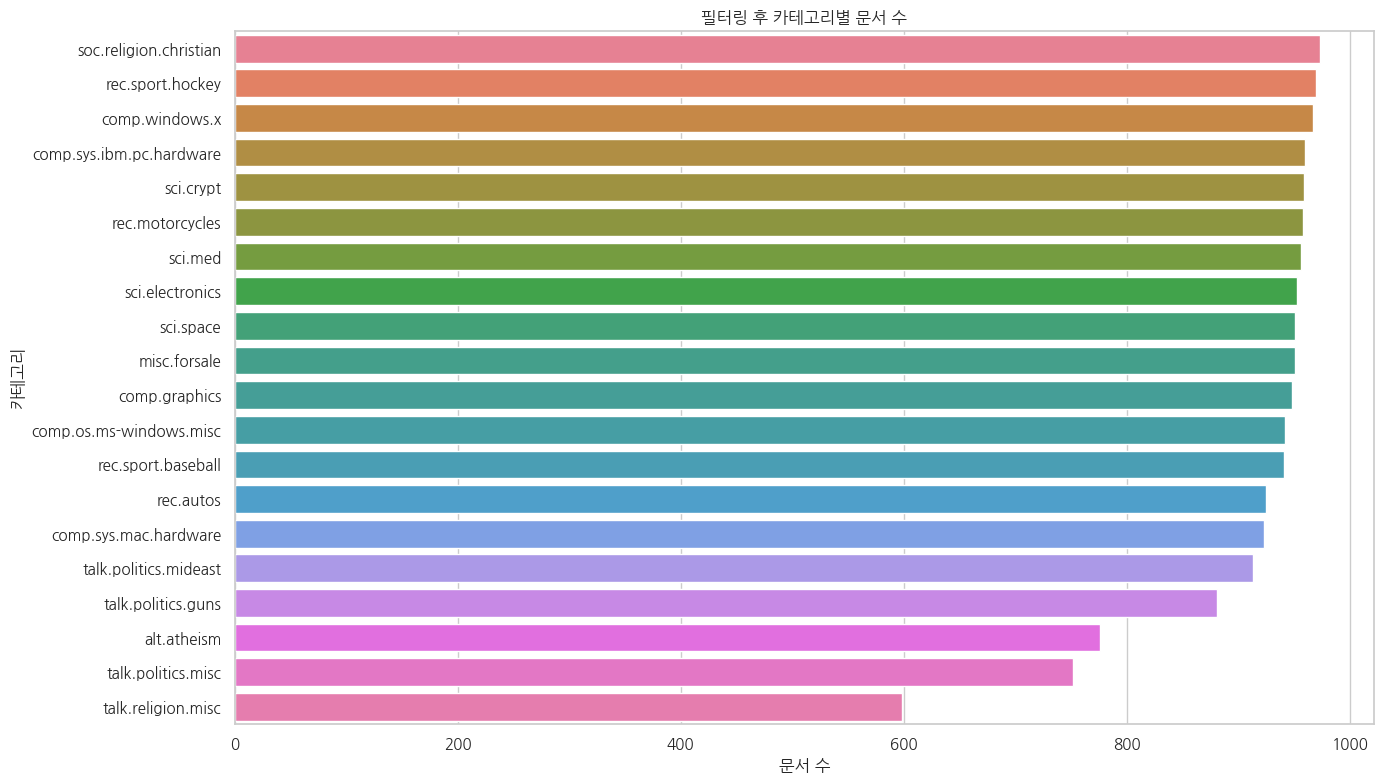

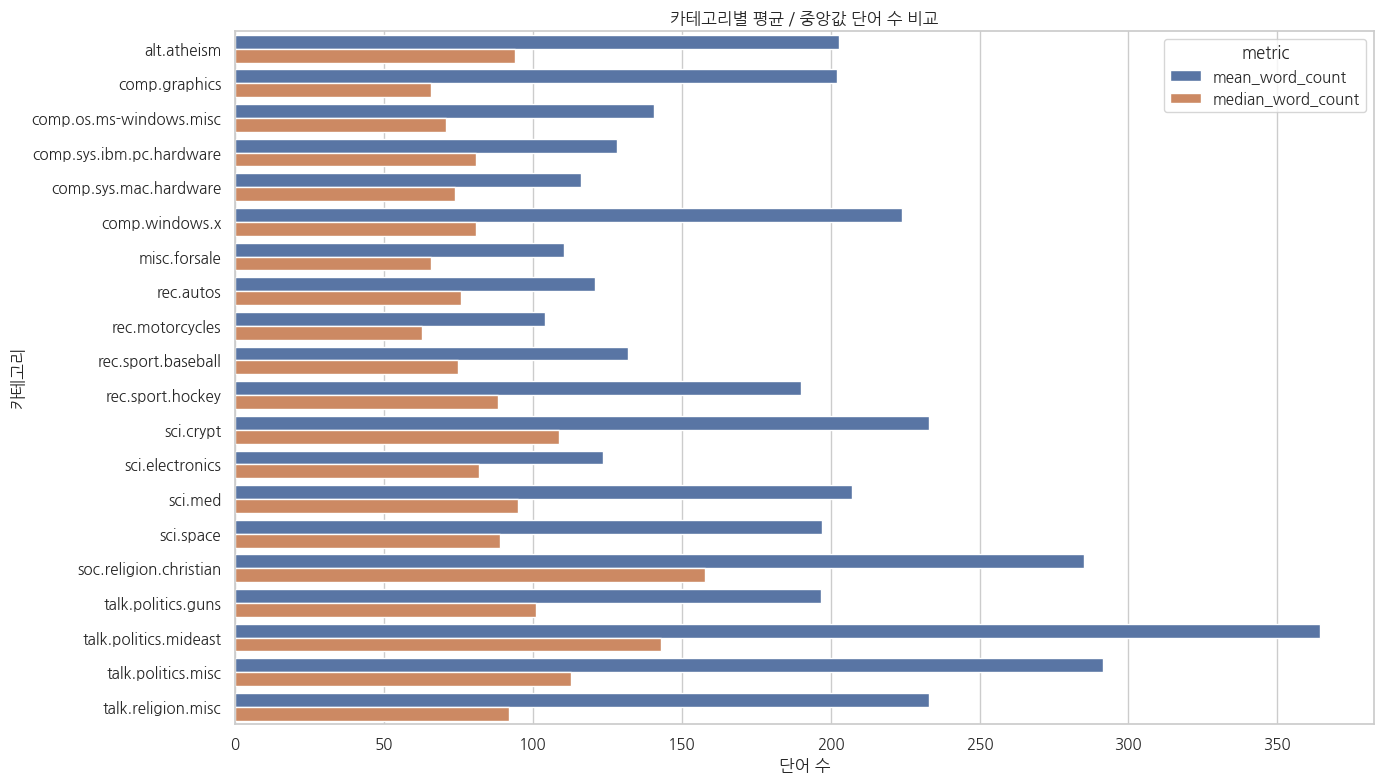

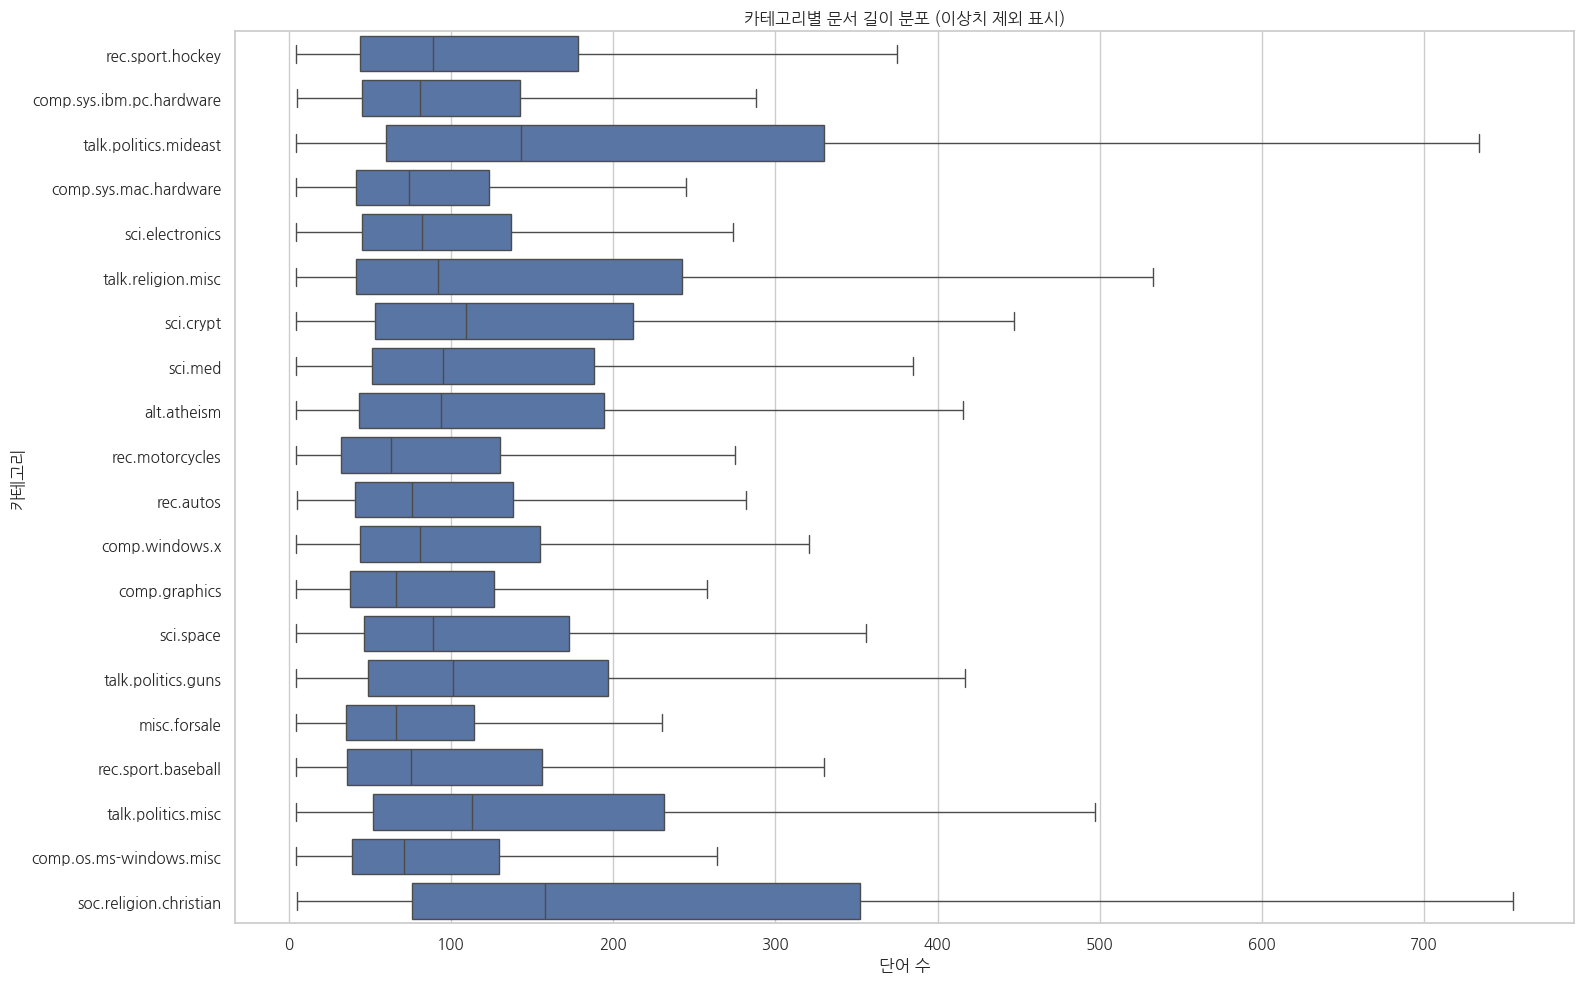

In [161]:
import seaborn as sns

sns.set_theme(style="whitegrid", rc={
    "font.family": "NanumGothic",
    "axes.unicode_minus": False
})

# -----------------------------
# 1. 카테고리별 문서 수 막대그래프
# -----------------------------
count_df = (
    newsgroups_refined_df
    .groupby('category')
    .size()
    .reset_index(name='doc_count')
    .sort_values('doc_count', ascending=False)
)

plt.figure(figsize=(14, 8))
sns.barplot(data=count_df, x='doc_count', y='category', hue='category', legend=False)

plt.title("필터링 후 카테고리별 문서 수")
plt.xlabel("문서 수")
plt.ylabel("카테고리")
plt.tight_layout()
plt.show()


# -----------------------------
# 2. 평균 / 중앙값 단어 수 비교
# -----------------------------
stats_reset = stats.reset_index()

plot_df = stats_reset.melt(
    id_vars='category',
    value_vars=['mean_word_count', 'median_word_count'],
    var_name='metric',
    value_name='word_count'
)

plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df, x='word_count', y='category', hue='metric')

plt.title("카테고리별 평균 / 중앙값 단어 수 비교")
plt.xlabel("단어 수")
plt.ylabel("카테고리")
plt.tight_layout()
plt.show()


# -----------------------------
# 3. 카테고리별 문서 길이 박스플롯
# -----------------------------
plt.figure(figsize=(16, 10))
sns.boxplot(
    data=newsgroups_refined_df,
    x='word_count',
    y='category',
    showfliers=False
)

plt.title("카테고리별 문서 길이 분포 (이상치 제외 표시)")
plt.xlabel("단어 수")
plt.ylabel("카테고리")
plt.tight_layout()
plt.show()

필터링 후의 클래스 별 문서 수는 528 ~ 973개 수준으로,   
최초 판단처럼 클래스 불균형이 심하지는 않은 상태가 유지되고 있습니다.  

카테고리 별 평균은 104 ~ 364로써  
rec.motorcycles 이 가장 적은 단어를 가지며  
talk.politics.mideast 가 가장 많은 단어를 가지는 것으로 집계되었습니다.  

카테고리 별 중위값은 63 ~ 158로 기사 내용이 대체적으로 그리 긴 내용은 아닌 것 (A4지 반장 분량)으로 확인됩니다.  
평균과 중위값의 차이는 평균보다 긴 문장이 평균을 크게 만드는 경향이 있다는 것으로 해석할 수 있습니다.  
따라서 중위값을 문서의 기준으로 더 신뢰하는게 옳다고 판단합니다.  

표준 편차가 아주 큰 카테고리들이 관측됩니다.  
| category              | std |
| --------------------- | --- |
| talk.politics.mideast | 841 |
| comp.windows.x        | 831 |
| comp.graphics         | 821 |
| talk.politics.misc    | 775 |

즉 padding 낭비가 크고 batch 효율의 저하가 우려됩니다.

위의 수치를 종합적으로 해석하면 아래와 같습니다.
1. 전체 데이터는 짧은 글이 다수고 소수의 초장문을 가진 구조입니다.
2. 정치/종료 카테고리는 장문 토론형이 많습니다.
3. 판매/취미/하드웨어 카테고리는 짧고 실용적일 확률이 높습니다.
4. Word2Vec, FastText, GloVe 세 임베딩 방식에서 충분히 작동합니다.
5. 문제가 있다면, 초장문 문서와 분산이 큰 카테고리에서의 학습 안정화입니다.

### f. 데이터 클랜징

다음과 같은 클랜징 기법을 사용합니다.

1. Lowercase 적용 : GloVe 사전 형식 일치를 위해 대소문자 혼용 문서를 소문자 단일로 처리합니다.
2. Usenet 잔여 노이즈 제거 : 정규식으로 이메일 주소, URL, 숫자, 특수문자를 제거 합니다.
3. NLTK word_tokenize 적용 : 단순 split() 함수보다 축약형 처리가 정확합니다.
4. 기사로 사용된 글이기 때문에 불용어를 적용하지 않습니다.
5. 최소 빈도 필터링을 적용합니다.

In [162]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/yopkigom/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

##### 시드 고정을 먼저 수행합니다.

In [ ]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

In [164]:
import re
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
from collections import Counter

# lowercase 변환
newsgroups_refined_df['text'] = newsgroups_refined_df['text'].apply(lambda x: x.lower())

# Usenet 잔여 노이즈 제거
newsgroups_refined_df['text'] = newsgroups_refined_df['text'].apply(lambda x: re.sub(r'\S+@\S+', '', x))
newsgroups_refined_df['text'] = newsgroups_refined_df['text'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))
newsgroups_refined_df['text'] = newsgroups_refined_df['text'].apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))

# 토큰화 전 분할 처리
train_texts, test_texts, train_labels, test_labels = train_test_split(newsgroups_refined_df['text'],
                                                                      newsgroups_refined_df['label'],
                                                                      stratify=newsgroups_refined_df['label'],
                                                                      test_size=0.2, random_state=SEED)
train_texts, val_texts, train_labels, val_labels   = train_test_split(train_texts, train_labels,
                                                                      test_size=0.125, random_state=SEED)
# 결과: train 70%, val 10%, test 20%

MIN_FREQ = 2

# NLTK word_tokenize, 단어 빈도 집계, 최소 빈도 필터링 적용 함수
def preprocess_and_tokenize(text_series, token_freq=None, min_freq=MIN_FREQ):
    tokens_series = text_series.apply(word_tokenize)

    if token_freq is None:  # train일 때만 빈도 산출
        all_tokens = [t for tokens in tokens_series for t in tokens]
        token_freq = Counter(all_tokens)

    filtered = tokens_series.apply(
        lambda tokens: [t if token_freq[t] >= min_freq else '<UNK>' for t in tokens]
    )
    return filtered, token_freq

train_inputs, train_freq = preprocess_and_tokenize(train_texts)
test_inputs, _           = preprocess_and_tokenize(test_texts, token_freq=train_freq)

### g. 카테고리 별 난이도 예측 비교

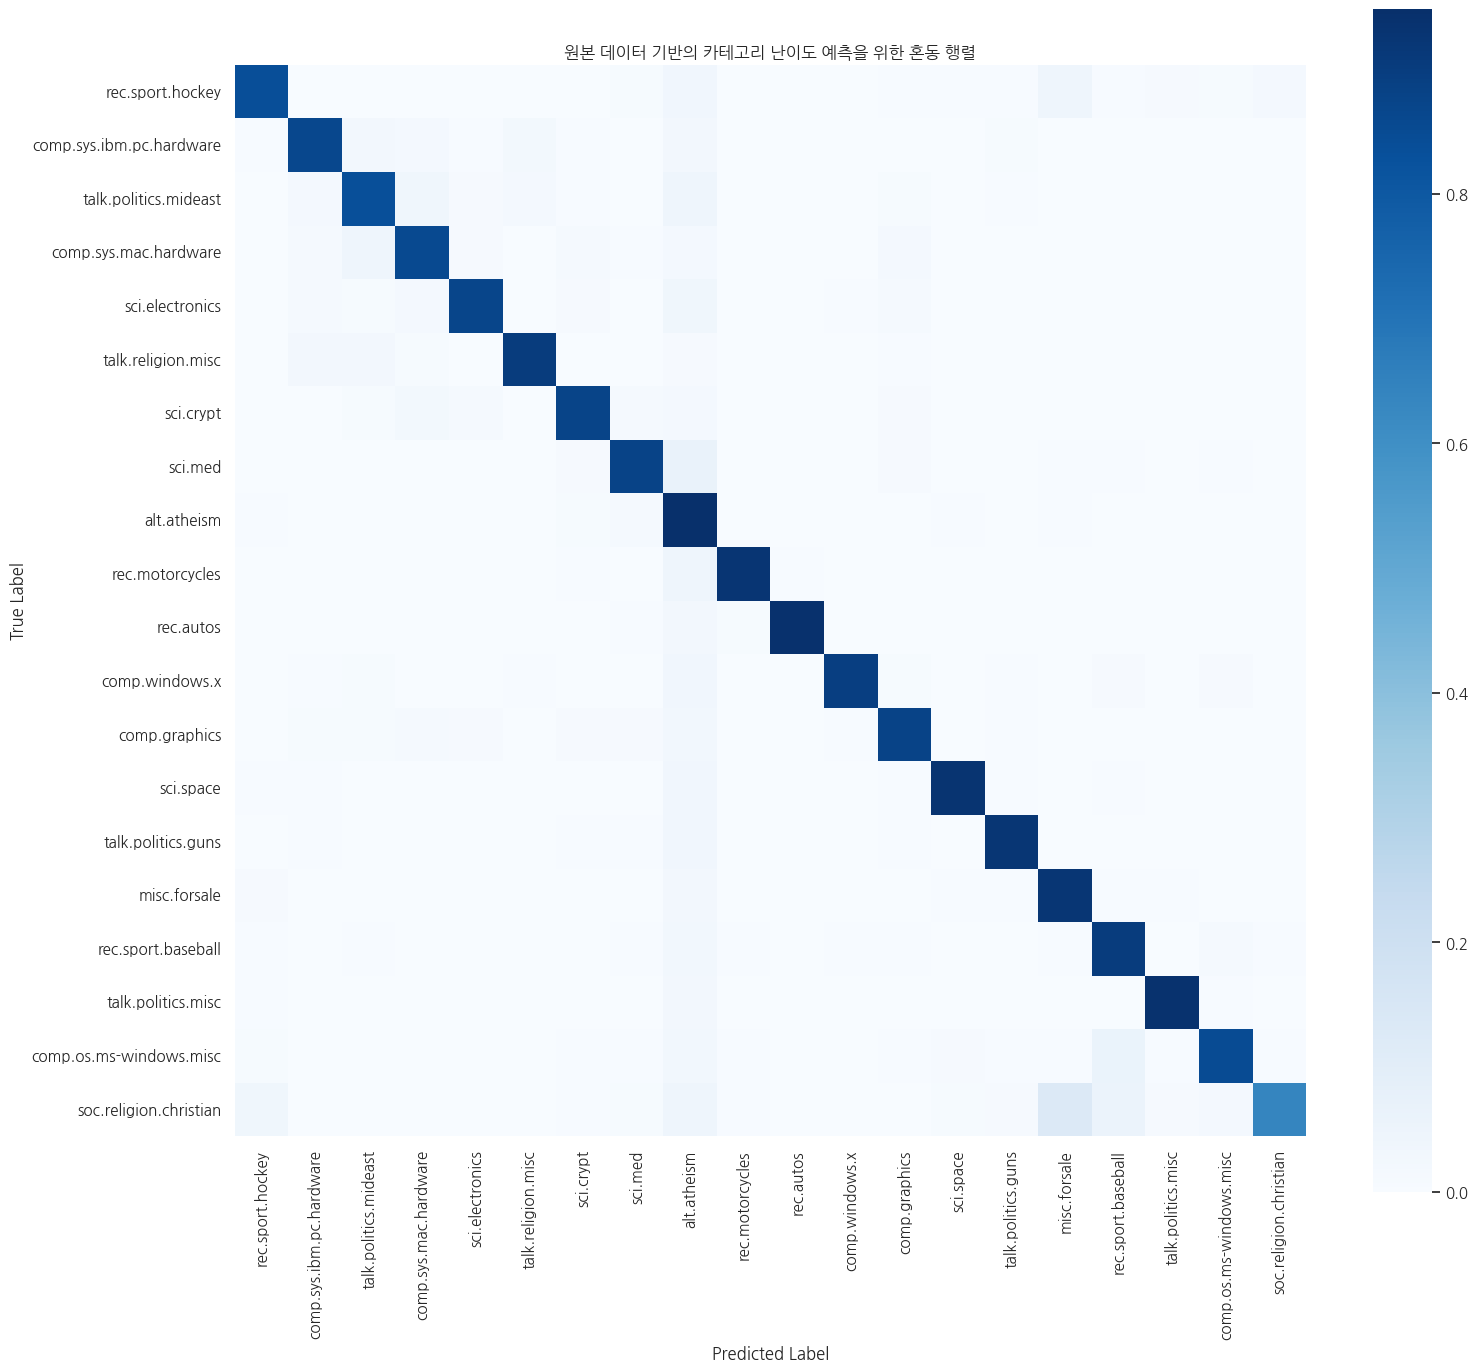

                          precision    recall  f1-score   support

        rec.sport.hockey       0.89      0.84      0.86       799
comp.sys.ibm.pc.hardware       0.88      0.87      0.87       973
   talk.politics.mideast       0.85      0.84      0.84       985
   comp.sys.mac.hardware       0.86      0.86      0.86       982
         sci.electronics       0.93      0.87      0.90       963
      talk.religion.misc       0.92      0.90      0.91       988
               sci.crypt       0.89      0.88      0.88       975
                 sci.med       0.91      0.88      0.89       990
             alt.atheism       0.61      0.95      0.74       996
         rec.motorcycles       0.96      0.93      0.95       994
               rec.autos       0.99      0.94      0.97       999
          comp.windows.x       0.96      0.89      0.93       991
           comp.graphics       0.88      0.88      0.88       984
               sci.space       0.94      0.93      0.94       990
      tal

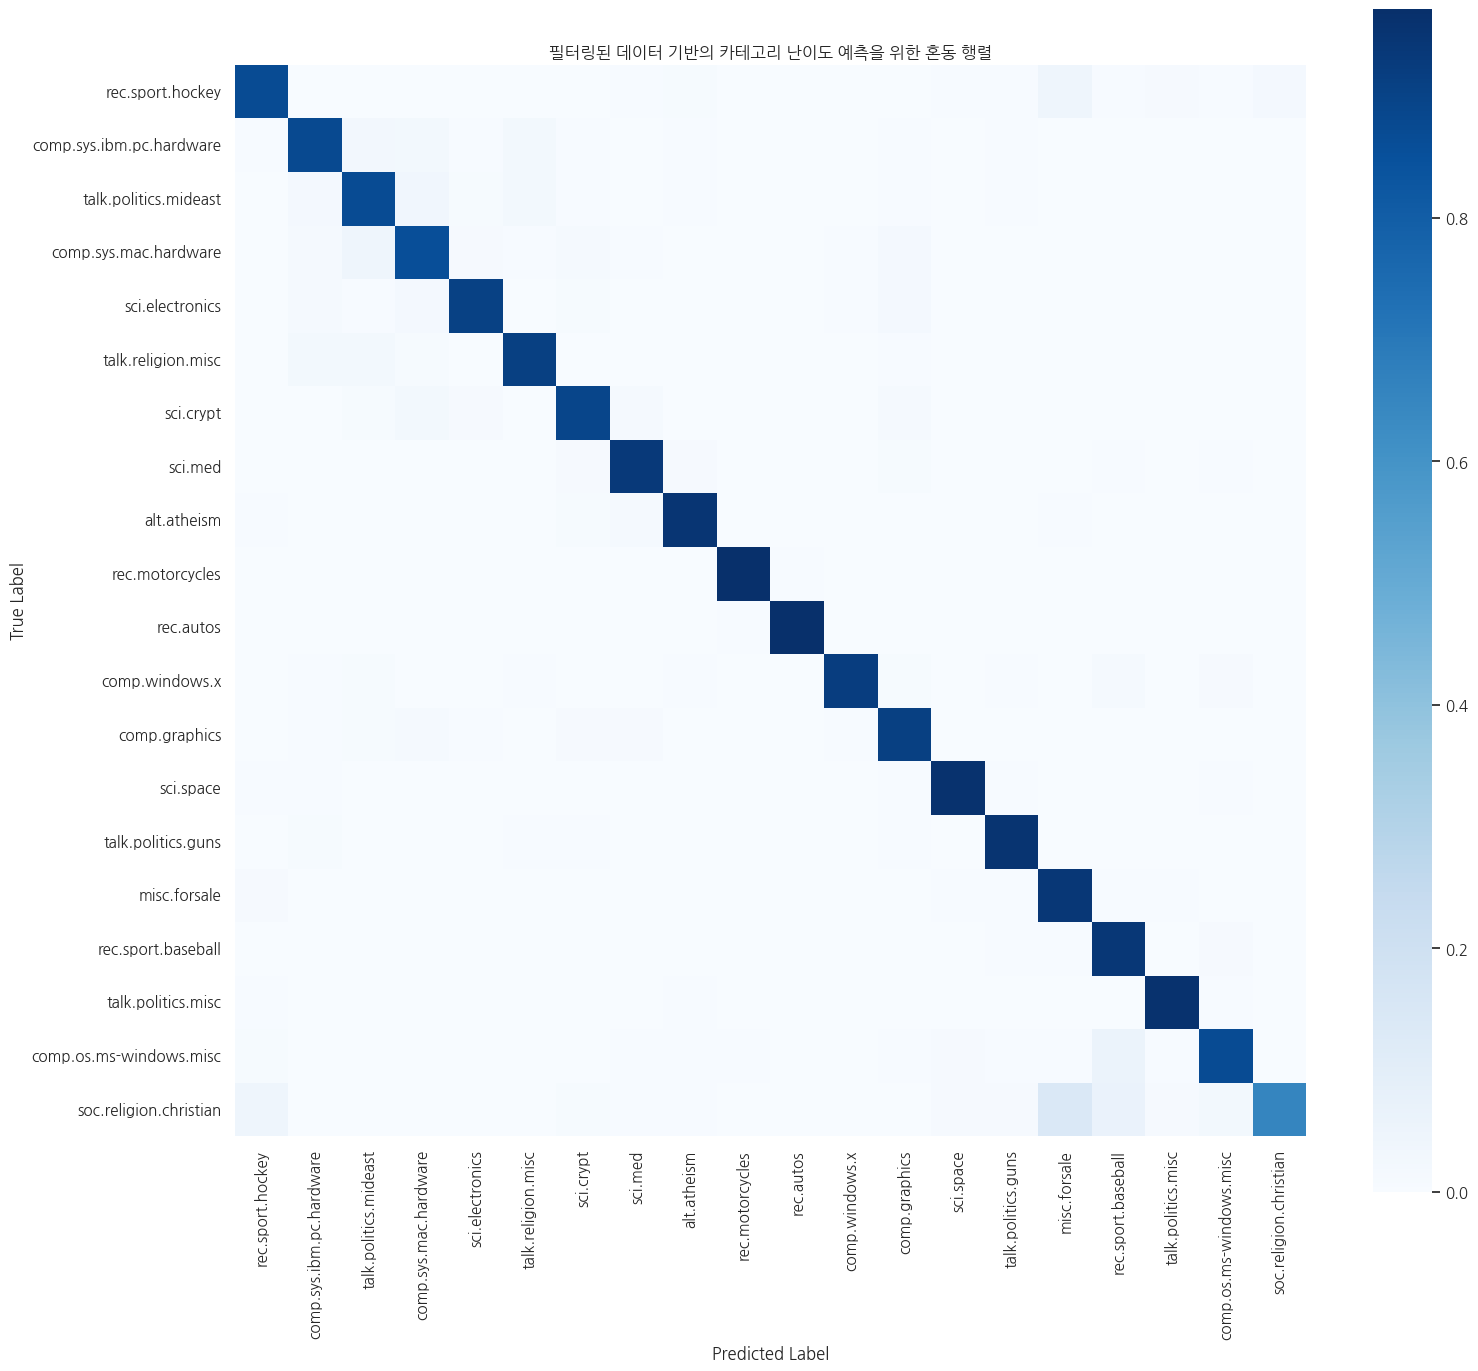

                          precision    recall  f1-score   support

        rec.sport.hockey       0.88      0.87      0.88       776
comp.sys.ibm.pc.hardware       0.87      0.88      0.87       948
   talk.politics.mideast       0.85      0.87      0.86       942
   comp.sys.mac.hardware       0.86      0.86      0.86       960
         sci.electronics       0.94      0.91      0.92       923
      talk.religion.misc       0.92      0.91      0.91       967
               sci.crypt       0.90      0.89      0.89       951
                 sci.med       0.93      0.94      0.93       925
             alt.atheism       0.92      0.95      0.94       958
         rec.motorcycles       0.97      0.97      0.97       941
               rec.autos       0.99      0.97      0.98       970
          comp.windows.x       0.96      0.92      0.94       959
           comp.graphics       0.88      0.91      0.90       953
               sci.space       0.94      0.96      0.95       956
      tal

In [165]:
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(target_df, title="카테고리 난이도 예측을 위한 혼동 행렬"):
    # -----------------------------
    # 1. 데이터 로드
    # -----------------------------
    train_data = target_df.copy()

    test_data = target_df.copy()

    X_train = train_data['text']
    y_train = train_data['label']

    X_test = test_data['text']
    y_test = test_data['label']

    target_names = train_data['category'].unique()

    # -----------------------------
    # 2. 모델 파이프라인
    # -----------------------------
    model = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words='english',
            max_df=0.9,
            min_df=5
        )),
        ("clf", LogisticRegression(
            max_iter=2000
        ))
    ])

    # -----------------------------
    # 3. 학습
    # -----------------------------
    model.fit(X_train, y_train)

    # -----------------------------
    # 4. 예측
    # -----------------------------
    y_pred = model.predict(X_test)

    # -----------------------------
    # 5. 혼동 행렬 계산
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred, normalize='true')

    # -----------------------------
    # 6. 시각화
    # -----------------------------
    plt.figure(figsize=(16, 14))

    sns.heatmap(
        cm,
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        square=True
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 7. 상세 리포트
    # -----------------------------
    print(classification_report(
        y_test,
        y_pred,
        target_names=target_names
    ))

# 원본 데이터로 혼동 행렬 출력
print_confusion_matrix(newsgroups_origin_df, title="원본 데이터 기반의 카테고리 난이도 예측을 위한 혼동 행렬")

# 필터링된 데이터로 혼동 행렬 출력
print_confusion_matrix(newsgroups_refined_df, title="필터링된 데이터 기반의 카테고리 난이도 예측을 위한 혼동 행렬")

데이터 클랜징 전/후의 차이가 선명히 드러납니다.  
특히 alt.atheism 이 모든 카테고리에 희미하게 영향을 주던 부분을 깔끔하게 처리할 수 있었습니다.  

전반적으로 카테고리의 진한 대각 배열이 확인되어 문서 구분이 명확할 것으로 예측됩니다.  

soc.religion.christian 카테고리는 문서 수도 작은데 recall과 f1-score 가  
다른 카테고리 대비 확연히 떨어지는 지표를 보이고 있어, 이 부분에 대한 변별력이 떨어질 것으로 예측됩니다.

TF-IDF 로 출력된 카테고리 별 평가 지표는 이후 RNN 기반 모델의 비교 지표로 사용하겠습니다.

## E. 임베딩 데이터 로더 구현

Word2Vec, FastText, GloVe 임베딩 모델을 사용하여 각각의 임베딩 메트릭스를 산출합니다.

### a. 공용 임베딩 환경 설정

In [ ]:
from enum import Enum
from torch.utils.data import Dataset
from gensim.models import Word2Vec, FastText
import urllib

# -------------------------------------------------------
# 1. 임베딩 타입 정의
# -------------------------------------------------------
class EmbeddingType(Enum):
    WORD2VEC = "word2vec"
    FASTTEXT = "fasttext"
    GLOVE    = "glove"
    
# -------------------------------------------------------
# 2. 어휘 사전 구축
# -------------------------------------------------------
class Vocabulary:
    PAD = '<PAD>'  # index 0
    UNK = '<UNK>'  # index 1

    def __init__(self, token_lists: list[list[str]], min_freq: int = 2):
        freq = Counter(t for tokens in token_lists for t in tokens)
        self.word2idx = {self.PAD: 0, self.UNK: 1}
        for word, count in freq.items():
            if count >= min_freq:
                self.word2idx[word] = len(self.word2idx)
        self.idx2word = {v: k for k, v in self.word2idx.items()}

    def __len__(self):
        return len(self.word2idx)

    def encode(self, tokens: list[str]) -> list[int]:
        unk = self.word2idx[self.UNK]
        return [self.word2idx.get(t, unk) for t in tokens]
    
# -------------------------------------------------------
# 3. 임베딩 매트릭스 빌더
# -------------------------------------------------------
EMBED_DIM   = 100
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_ZIP = "glove.6B.zip"
GLOVE_FILE = "glove.6B.100d.txt"

def build_embedding_matrix(
    vocab: Vocabulary,
    embedding_type: EmbeddingType,
    token_lists: list[list[str]] | None = None,
    seed: int = SEED,
) -> torch.Tensor:

    vocab_size = len(vocab)
    matrix = np.zeros((vocab_size, EMBED_DIM), dtype=np.float32)

    if embedding_type == EmbeddingType.WORD2VEC:
        model = Word2Vec(
            sentences=token_lists,
            vector_size=EMBED_DIM,
            window=5,
            min_count=2,
            workers=4,
            epochs=20,
            seed=seed,
        )
        for word, idx in vocab.word2idx.items():
            if word in model.wv:
                matrix[idx] = model.wv[word]

    elif embedding_type == EmbeddingType.FASTTEXT:
        model = FastText(
            sentences=token_lists,
            vector_size=EMBED_DIM,
            window=5,
            min_count=2,
            workers=4,
            epochs=20,
            seed=seed,
        )
        for word, idx in vocab.word2idx.items():
            if word in model.wv:
                matrix[idx] = model.wv[word]

    elif embedding_type == EmbeddingType.GLOVE:
        if not os.path.exists(GLOVE_FILE):
            print("Downloading GloVe embeddings...")
            urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
            import zipfile
            with zipfile.ZipFile(GLOVE_ZIP, 'r') as zip_ref:
                zip_ref.extractall()
            print("GloVe embeddings downloaded and extracted.")
        else:
            print("GloVe embeddings already available.")
        
        glove_vectors = {}
        with open(GLOVE_FILE, encoding='utf-8') as f:
            for line in f:
                parts = line.split()
                glove_vectors[parts[0]] = np.array(parts[1:], dtype=np.float32)

        for word, idx in vocab.word2idx.items():
            if word in glove_vectors:
                matrix[idx] = glove_vectors[word]

    else:
        raise ValueError(f"지원하지 않는 임베딩 타입: {embedding_type}")

    return torch.tensor(matrix)


### b. 공용 데이터 클래스 구현

In [167]:
class TextEmbeddingDataset(Dataset):

    def __init__(
        self,
        token_lists: list[list[str]],
        labels: list[int],
        vocab: Vocabulary,
        max_seq_len: int,
    ):
        if len(token_lists) != len(labels):
            raise ValueError("token_lists와 labels의 길이가 다릅니다.")

        self.labels      = labels
        self.max_seq_len = max_seq_len
        self.encoded     = [vocab.encode(tokens) for tokens in token_lists]

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        seq = self.encoded[idx][:self.max_seq_len]  # truncate

        # post-padding (PAD index = 0)
        pad_len = self.max_seq_len - len(seq)
        seq = seq + [0] * pad_len

        return (
            torch.tensor(seq,              dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

### c. 임베딩 메트릭스 생성

In [ ]:
from torch.utils.data import DataLoader

val_inputs, _ = preprocess_and_tokenize(val_texts, token_freq=train_freq)

train_token_lists = train_inputs.tolist()
train_label_list  = train_labels.tolist()

val_token_lists   = val_inputs.tolist()
val_label_list    = val_labels.tolist()

test_token_lists  = test_inputs.tolist()
test_label_list   = test_labels.tolist()

# max_seq_len: 앞서 산출한 95 백분위수 사용
MAX_SEQ_LEN = int(np.percentile([len(tokens) for tokens in train_token_lists], 95))

train_vocab = Vocabulary(train_token_lists, min_freq=2)

logger.info(f"Vocab size: {len(train_vocab)}")
logger.info(f"MAX_SEQ_LEN (train 95th): {MAX_SEQ_LEN}")
logger.info(f"Split sizes — train: {len(train_label_list)}, "
            f"val: {len(val_label_list)}, test: {len(test_label_list)}")

# 임베딩 매트릭스 생성 — 세 방식 모두 동일 vocab 사용
train_matrix_w2v  = build_embedding_matrix(train_vocab, EmbeddingType.WORD2VEC, train_token_lists)
train_matrix_ft   = build_embedding_matrix(train_vocab, EmbeddingType.FASTTEXT,  train_token_lists)
train_matrix_glove = build_embedding_matrix(train_vocab, EmbeddingType.GLOVE,   train_token_lists)

# Dataset / DataLoader
BATCH_SIZE = 64

train_dataset = TextEmbeddingDataset(train_token_lists, train_label_list, train_vocab, MAX_SEQ_LEN)
val_dataset   = TextEmbeddingDataset(val_token_lists,   val_label_list,   train_vocab, MAX_SEQ_LEN)
test_dataset  = TextEmbeddingDataset(test_token_lists,  test_label_list,  train_vocab, MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

[2026-05-15 15:50:21.637] [INFO] Vocab size: 37957
[2026-05-15 15:50:21.638] [INFO] MAX_SEQ_LEN (train 95th): 567
[2026-05-15 15:50:21.638] [INFO] Split sizes — train: 12737, val: 1820, test: 3640
[2026-05-15 15:50:21.641] [INFO] collecting all words and their counts
[2026-05-15 15:50:21.641] [INFO] PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
[2026-05-15 15:50:21.815] [INFO] PROGRESS: at sentence #10000, processed 1904679 words, keeping 36674 word types
[2026-05-15 15:50:21.862] [INFO] collected 37956 word types from a corpus of 2455932 raw words and 12737 sentences
[2026-05-15 15:50:21.863] [INFO] Creating a fresh vocabulary
[2026-05-15 15:50:21.914] [INFO] Word2Vec lifecycle event {'msg': 'effective_min_count=2 retains 37956 unique words (100.00% of original 37956, drops 0)', 'datetime': '2026-05-15T15:50:21.913991', 'gensim': '4.4.0', 'python': '3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:50:00) [GCC 14.3.0]', 'platform': 'Linux-6.6.87.2-microsof

GloVe embeddings already available.


## F. GRU 와 LSTM 특성 분석 및 RNN 모델 설계

### a. GRU의 특성

1. 구조적 특징 : 통합된 2개의 게이트
    - Update Gate : 과거와 현재 정보의 업데이트 비율을 결정합니다. (LSTM의 Forget + Input 역할)
    - Reset Gate : 과거 정보를 얼마나 무시할지 결정합니다.
    - Cell State 없이 Hidden State 하나로 정보를 전달합니다.

2. 자연어 처리에서의 장단점
    - 장점 : 파라미터 수가 LSTM 대비 적어 메모리를 적게 사용하고 빠릅니다.  
    적은 양의 데이터 셋에서도 일반화 성능이 좋습니다.
    - 단점 : 정보 제어의 정교함이 LSTM에 비해 떨어질 수 있고,  
    매우 길고 복잡한 종속성을 가진 데이터에서는 LSTM 보다 성능이 떨어질 수 있습니다.

### b. LSTM의 특성

1. 구조적 특징 : 3개의 게이트
    - Forget Gate : 과거 정보를 얼마나 버릴지 결정
    - Input Gate : 현재 정보를 얼마나 저장할지 결정
    - Output Gate : 어떤 부분을 출력으로 내보낼지 결정

2. 자연어 처리에서의 장단점
    - 장점 : 매우 긴 문맥에서 GRU 보다 더 세밀한 제어가 가능하며, 데이터가 많을 때 성능이 안정적입니다.
    - 단점 : 파라미터 수가 많아 메모리를 많이 점유하고 느립니다. 과적합 위험이 GRU 보다 높습니다.

### c. RNN 모델 구현

GRU와 LSTM 을 선택하여 인스턴스를 생성할 수 있고,  
외부로부터 임베딩 메트릭스를 주입받을 수 있도록 인자 값을 설정합니다.

In [ ]:
from enum import Enum

class RNNType(Enum):
    LSTM = "lstm"
    GRU  = "gru"


class NewsClassifierRNN(nn.Module):

    def __init__(
        self,
        embedding_matrix: torch.Tensor,  # (vocab_size, embed_dim)
        num_classes: int,
        rnn_type: RNNType = RNNType.LSTM,
        hidden_dim: int = 128,
        num_layers: int = 2,
        dropout: float = 0.3,
        freeze_embedding: bool = False,
    ):
        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape

        # Embedding layer — pre-trained matrix 주입
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(embedding_matrix)
        self.embedding.weight.requires_grad = not freeze_embedding

        # RNN layer — LSTM / GRU 공용 분기
        rnn_cls = {
            RNNType.LSTM: nn.LSTM,
            RNNType.GRU:  nn.GRU,
        }.get(rnn_type)

        if rnn_cls is None:
            raise ValueError(f"지원하지 않는 RNN 타입: {rnn_type}")

        self.rnn = rnn_cls(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        self.rnn_type = rnn_type
        self.dropout  = nn.Dropout(dropout)

        # Bidirectional 이므로 hidden_dim * 2
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len)
        embedded = self.dropout(self.embedding(x))       # (batch, seq_len, embed_dim)

        if self.rnn_type == RNNType.LSTM:
            _, (hidden, _) = self.rnn(embedded)          # hidden: (num_layers*2, batch, hidden_dim)
        else:
            _, hidden = self.rnn(embedded)

        # 마지막 레이어의 forward / backward hidden 결합
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, hidden_dim*2)
        return self.fc(self.dropout(hidden))                 # (batch, num_classes)


## G. 학습 진행

총 6가지 모델을 조건을 설정하여 학습을 진행합니다.

GRU or LSTM RNN + Word2Vec or FastText or GloVe

### a. 예제 기반 베이스라인 하이퍼파라미터 설정

In [170]:
# 하이퍼파라미터 설정
hidden_size = 256                # LSTM 은닉 상태 크기
num_layers = 3                   # LSTM 레이어 수
num_classes = len(category_names)
dropout = 0.3
num_epochs = 20
learning_rate = 1e-4
batch_size = 64

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"사용 가능한 디바이스: {device}")

In [ ]:
import json
import pickle
import torch.nn as nn

# -------------------------------------------------------
# 프로젝트 저장 경로 설정
# -------------------------------------------------------
if is_colab:
    PROJECT_DIR = os.path.join(MOUNT_PATH, "MyDrive", "sprint10_checkpoints")
else:
    PROJECT_DIR = os.path.join(os.getcwd(), "sprint10_checkpoints")

os.makedirs(PROJECT_DIR, exist_ok=True)
logger.info(f"체크포인트 저장 경로: {PROJECT_DIR}")


# -------------------------------------------------------
# 저장 / 로드 유틸리티
# -------------------------------------------------------
def save_checkpoint(
    model: nn.Module,
    history: dict,
    model_name: str,
    epoch: int,
    optimizer=None,
    scheduler=None,
    is_best: bool = False,
):
    """모델 체크포인트를 PROJECT_DIR에 저장."""
    ckpt = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "history": history,
        "model_name": model_name,
    }
    if optimizer is not None:
        ckpt["optimizer_state_dict"] = optimizer.state_dict()
    if scheduler is not None:
        ckpt["scheduler_state_dict"] = scheduler.state_dict()

    tag = "best" if is_best else f"ep{epoch}"
    path = os.path.join(PROJECT_DIR, f"{model_name}_{tag}.pt")
    torch.save(ckpt, path)
    logger.info(f"[{model_name}] Checkpoint saved → {path}")


def load_checkpoint(model_name: str, tag: str = "best") -> dict | None:
    """저장된 체크포인트 로드. 없으면 None 반환."""
    path = os.path.join(PROJECT_DIR, f"{model_name}_{tag}.pt")
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=device, weights_only=False)
        logger.info(f"[{model_name}] Checkpoint loaded ← {path}")
        return ckpt
    return None


def save_experiment_env():
    """하이퍼파라미터, vocab, 학습 환경 정보를 JSON + pickle로 저장."""
    env_info = {
        "seed": SEED,
        "embed_dim": EMBED_DIM,
        "max_seq_len": MAX_SEQ_LEN,
        "batch_size": BATCH_SIZE,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "num_classes": num_classes,
        "dropout": dropout,
        "num_epochs": num_epochs,
        "learning_rate": learning_rate,
        "min_freq": MIN_FREQ,
        "vocab_size": len(train_vocab),
        "split_sizes": {
            "train": len(train_label_list),
            "val": len(val_label_list),
            "test": len(test_label_list),
        },
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A",
    }

    # 하이퍼파라미터 (사람이 읽을 수 있는 JSON)
    with open(os.path.join(PROJECT_DIR, "experiment_env.json"), "w") as f:
        json.dump(env_info, f, indent=2, ensure_ascii=False)

    # Vocab (복원에 필요)
    with open(os.path.join(PROJECT_DIR, "train_vocab.pkl"), "wb") as f:
        pickle.dump(train_vocab, f)

    # 임베딩 매트릭스 (재생성에 10분+ 소요되므로 캐싱)
    torch.save({
        "w2v": train_matrix_w2v,
        "ft": train_matrix_ft,
        "glove": train_matrix_glove,
    }, os.path.join(PROJECT_DIR, "embedding_matrices.pt"))

    logger.info(f"실험 환경 저장 완료 → {PROJECT_DIR}")


def save_all_histories(histories: dict):
    """전체 학습 history를 JSON으로 저장."""
    # history 내 값들을 JSON 직렬화 가능한 형태로 변환
    serializable = {}
    for name, h in histories.items():
        serializable[name] = {
            k: [float(v) for v in vals] if isinstance(vals, list) else vals
            for k, vals in h.items()
        }
    path = os.path.join(PROJECT_DIR, "all_histories.json")
    with open(path, "w") as f:
        json.dump(serializable, f, indent=2)
    logger.info(f"전체 학습 히스토리 저장 완료 → {path}")

### b. GRU RNN 모델 인스턴스

In [171]:
model_gru_rnn_w2v = NewsClassifierRNN(
    embedding_matrix=train_matrix_w2v,
    num_classes=num_classes,
    rnn_type=RNNType.GRU,
    hidden_dim=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    freeze_embedding=False,
)

model_gru_rnn_ft = NewsClassifierRNN(
    embedding_matrix=train_matrix_ft,
    num_classes=num_classes,
    rnn_type=RNNType.GRU,
    hidden_dim=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    freeze_embedding=False,
)

model_gru_rnn_glove = NewsClassifierRNN(
    embedding_matrix=train_matrix_glove,
    num_classes=num_classes,
    rnn_type=RNNType.GRU,
    hidden_dim=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    freeze_embedding=False,
)

### c. LSTM RNN 모델 인스턴스

In [172]:
model_lstm_rnn_w2v = NewsClassifierRNN(
    embedding_matrix=train_matrix_w2v,
    num_classes=num_classes,
    rnn_type=RNNType.LSTM,
    hidden_dim=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    freeze_embedding=False,
)

model_lstm_rnn_ft = NewsClassifierRNN(
    embedding_matrix=train_matrix_ft,
    num_classes=num_classes,
    rnn_type=RNNType.LSTM,
    hidden_dim=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    freeze_embedding=False,
)

model_lstm_rnn_glove = NewsClassifierRNN(
    embedding_matrix=train_matrix_glove,
    num_classes=num_classes,
    rnn_type=RNNType.LSTM,
    hidden_dim=hidden_size,
    num_layers=num_layers,
    dropout=dropout,
    freeze_embedding=False,
)

### d. 모델 연산 장치 설정

In [ ]:
model_gru_rnn_w2v.to(device)
model_gru_rnn_ft.to(device)
model_gru_rnn_glove.to(device)
model_lstm_rnn_w2v.to(device)
model_lstm_rnn_ft.to(device)    
model_lstm_rnn_glove.to(device)

[2026-05-15 16:01:10.062] [INFO] 사용 가능한 디바이스: cuda


NewsClassifierRNN(
  (embedding): Embedding(37957, 100, padding_idx=0)
  (rnn): LSTM(100, 256, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=20, bias=True)
)

### d. 학습 로직

In [ ]:
from copy import deepcopy

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    model_name: str = "model",
    num_epochs: int = num_epochs,
    learning_rate: float = learning_rate,
    patience: int = 7,
    min_delta: float = 1e-4,
    max_grad_norm: float = 1.0,
):
    """
    Early stopping + best checkpoint 기반 학습 루프.

    Args:
        patience:     val_loss가 min_delta 이상 개선되지 않는 epoch 허용 횟수
        min_delta:    개선으로 인정하는 최소 loss 감소량
        max_grad_norm: gradient clipping 임계값
        model_name:   로그/체크포인트 식별용 이름

    Returns:
        history dict (train_loss, val_loss, val_acc, best_epoch, stopped_epoch)
    """
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, verbose=False
    )

    history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'lr':[], 'best_epoch': 0, 'stopped_epoch': 0}

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    wait = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_train_loss = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm) # gradient explosion 방지
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        
        model.eval()
        total_val_loss = 0
        correct = 0
        total_samples = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                total_val_loss += criterion(outputs, labels).item()

                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_acc = (correct / total_samples) * 100
        
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(avg_val_loss)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        history['lr'].append(current_lr)
        
        logger.info(
            f"[{model_name}] Epoch [{epoch}/{num_epochs}] "
            f"- Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, "
            f"Val Acc: {avg_val_acc:.2f}%, LR: {current_lr:.2e}"
        )
        
        # ---- Early stopping check ----
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            wait = 0
            
            save_checkpoint(
                model, history, model_name, epoch,
                optimizer=optimizer, scheduler=scheduler,
                is_best=True,
            )
        else:
            wait += 1
            if wait >= patience:
                logger.info(
                    f"[{model_name}] Early stopping at epoch {epoch}. "
                    f"Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f})"
                )
                break
    
    # ---- Best 모델 복원 ----
    if best_state is not None:
        model.load_state_dict(best_state)
        logger.info(f"[{model_name}] Best model restored from epoch {best_epoch}.")

    history['best_epoch'] = best_epoch
    history['stopped_epoch'] = epoch
    
    return history

### e. 모델 별 학습 진행

In [ ]:
save_experiment_env()

MODELS = {
    "GRU_W2V":   model_gru_rnn_w2v,
    "GRU_FT":    model_gru_rnn_ft,
    "GRU_GloVe": model_gru_rnn_glove,
    "LSTM_W2V":  model_lstm_rnn_w2v,
    "LSTM_FT":   model_lstm_rnn_ft,
    "LSTM_GloVe": model_lstm_rnn_glove,
}

# 기존 history 복원 시도
history_path = os.path.join(PROJECT_DIR, "all_histories.json")
if os.path.exists(history_path):
    with open(history_path, "r") as f:
        histories = json.load(f)
    logger.info(f"이전 학습 기록 복원: {list(histories.keys())}")
else:
    histories = {}

for name, model in MODELS.items():
    # 이미 완료된 모델은 checkpoint만 복원하고 skip
    if name in histories and "best_epoch" in histories[name]:
        ckpt = load_checkpoint(name, tag="best")
        if ckpt is not None:
            model.load_state_dict(ckpt["model_state_dict"])
            logger.info(f"[{name}] 이전 best 모델 복원 완료 — 학습 skip")
            continue

    logger.info(f"{'='*60}")
    logger.info(f"학습 시작: {name}")
    logger.info(f"{'='*60}")

    histories[name] = train_model(
        model, train_loader, val_loader,
        model_name=name,
    )
    save_all_histories(histories)

logger.info("전체 학습 완료.")

[2026-05-15 16:02:05.094] [INFO] Epoch [1/20] - Loss: 2.7575
[2026-05-15 16:02:10.160] [INFO] Epoch [1/20] - Val Loss: 2.3540, Val Acc: 22.42%
[2026-05-15 16:02:58.159] [INFO] Epoch [2/20] - Loss: 2.1912
[2026-05-15 16:03:02.673] [INFO] Epoch [2/20] - Val Loss: 2.0103, Val Acc: 31.86%
[2026-05-15 16:03:52.140] [INFO] Epoch [3/20] - Loss: 1.9770
[2026-05-15 16:03:56.693] [INFO] Epoch [3/20] - Val Loss: 1.8144, Val Acc: 37.86%
[2026-05-15 16:04:47.285] [INFO] Epoch [4/20] - Loss: 1.8284
[2026-05-15 16:04:54.735] [INFO] Epoch [4/20] - Val Loss: 1.7217, Val Acc: 40.19%
[2026-05-15 16:05:45.439] [INFO] Epoch [5/20] - Loss: 1.6912
[2026-05-15 16:05:50.519] [INFO] Epoch [5/20] - Val Loss: 1.5853, Val Acc: 45.40%
[2026-05-15 16:06:42.814] [INFO] Epoch [6/20] - Loss: 1.5734
[2026-05-15 16:06:47.953] [INFO] Epoch [6/20] - Val Loss: 1.5113, Val Acc: 48.23%
[2026-05-15 16:07:40.002] [INFO] Epoch [7/20] - Loss: 1.4707
[2026-05-15 16:07:47.002] [INFO] Epoch [7/20] - Val Loss: 1.4215, Val Acc: 50.15%